In [27]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
import xgboost as xgb
import matplotlib.pyplot as plt

import openbb as obb
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import norm, skewnorm, t

<Axes: >

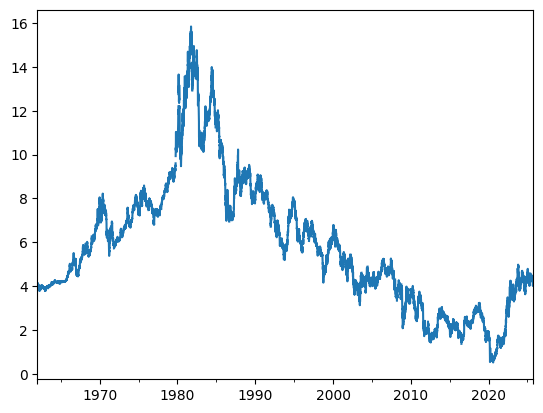

In [28]:
from fredapi import Fred

fred = Fred(api_key='1d66ac86e85e0a552a9c3f463c161295')

# Example: 10-Year Treasury Constant Maturity Rate (DGS10)
yield_10y = fred.get_series('DGS10')

yield_10y.plot()

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GC=F']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [GC=F]
Index: []


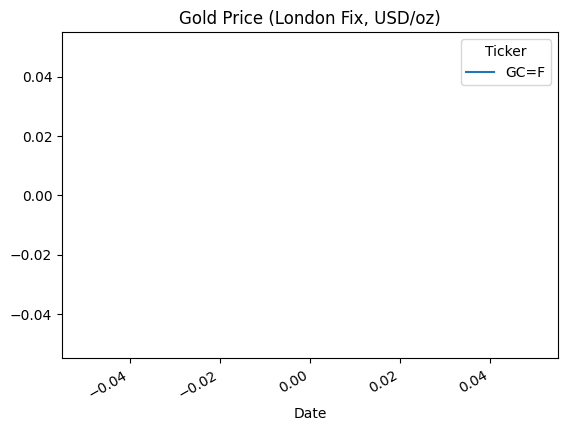

In [29]:
gold = fred.get_series("IR14270")
import yfinance as yf
gold_yahoo = yf.download("GC=F", start="2001-01-01")["Close"]
print(gold_yahoo)


gold_yahoo.plot(title="Gold Price (London Fix, USD/oz)")
plt.show()

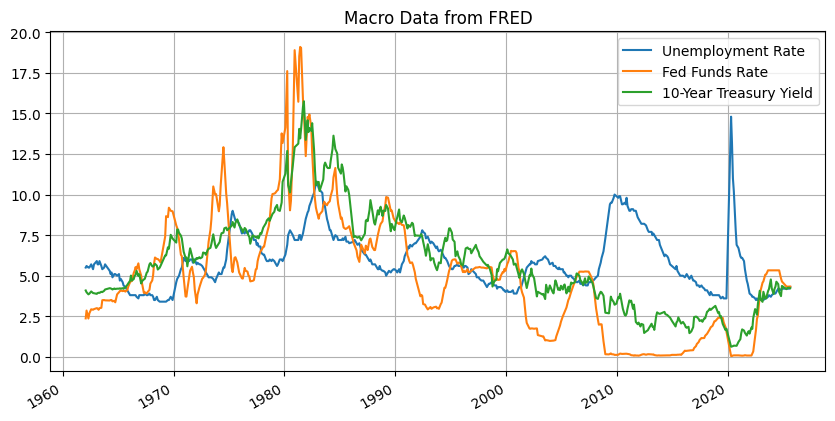

In [30]:
fred = Fred(api_key="1d66ac86e85e0a552a9c3f463c161295")

# Define series of interest
series = {
    'CPI (Inflation)': 'CPIAUCSL',
    'Unemployment Rate': 'UNRATE',
    'GDP (US)': 'GDP',
    'Fed Funds Rate': 'FEDFUNDS',
    '10-Year Treasury Yield': 'DGS10'
}

# Fetch data
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data[[ 'Unemployment Rate', 'Fed Funds Rate', '10-Year Treasury Yield']].dropna().plot(
    figsize=(10, 5), title="Macro Data from FRED"
)
plt.grid(True)
plt.show()

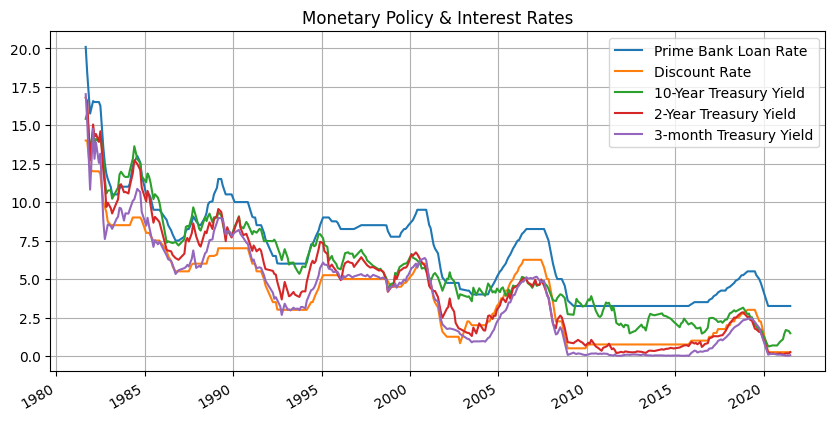

In [31]:
fred = Fred(api_key="1d66ac86e85e0a552a9c3f463c161295")

# Define series of interest
series = {
    'Prime Bank Loan Rate': 'MPRIME',
    'Discount Rate': 'INTDSRUSM193N',
    '10-Year Treasury Yield': 'DGS10',
    '2-Year Treasury Yield': 'DGS2',
    '3-month Treasury Yield': 'DGS3MO',
}

# Fetch data
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data.dropna().plot(
    figsize=(10, 5), title="Monetary Policy & Interest Rates"
)
plt.grid(True)
plt.show()

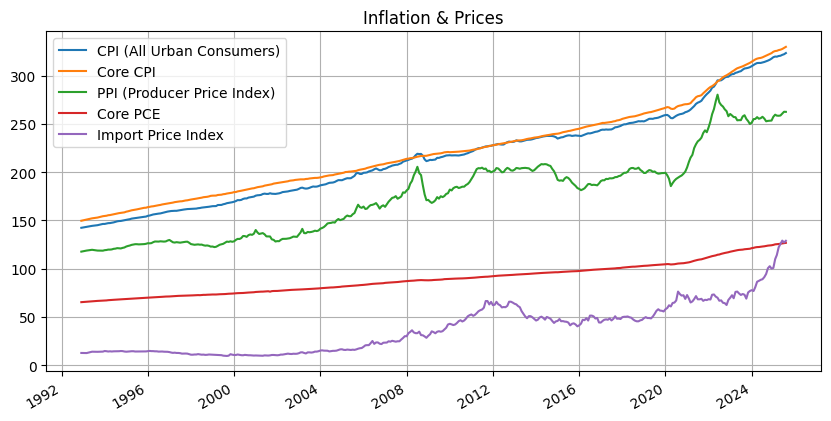

In [32]:
series = {
    'CPI (All Urban Consumers)':	'CPIAUCSL',
'Core CPI':	'CPILFESL',
'PPI (Producer Price Index)':	'PPIACO',
'Core PCE':	'PCEPILFE',
'Import Price Index':	'IR14270',
}
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data.dropna().plot(
    figsize=(10, 5), title="Inflation & Prices"
)
plt.grid(True)
plt.show()

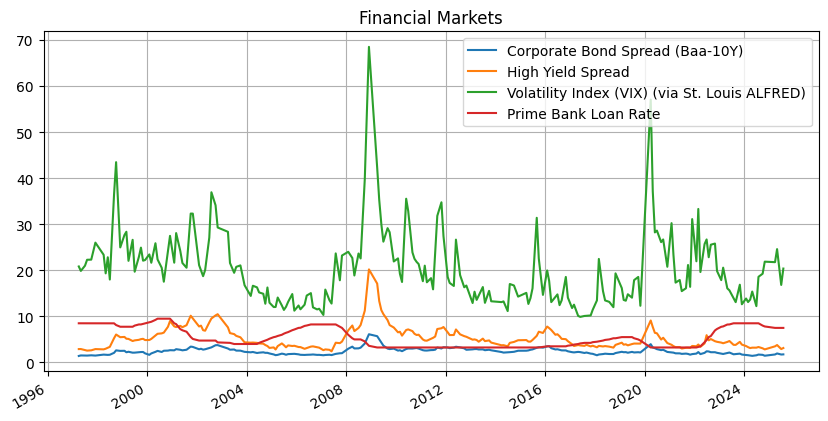

In [33]:


series = {
    #'S&P 500 Index':	'SP500',
'Corporate Bond Spread (Baa-10Y)':	'BAA10Y',
'High Yield Spread':	'BAMLH0A0HYM2',
'Volatility Index (VIX) (via St. Louis ALFRED)':	'VIXCLS',
'Prime Bank Loan Rate': 'MPRIME',
}
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data.dropna().plot(
    figsize=(10, 5), title="Financial Markets"
)
plt.grid(True)
plt.show()

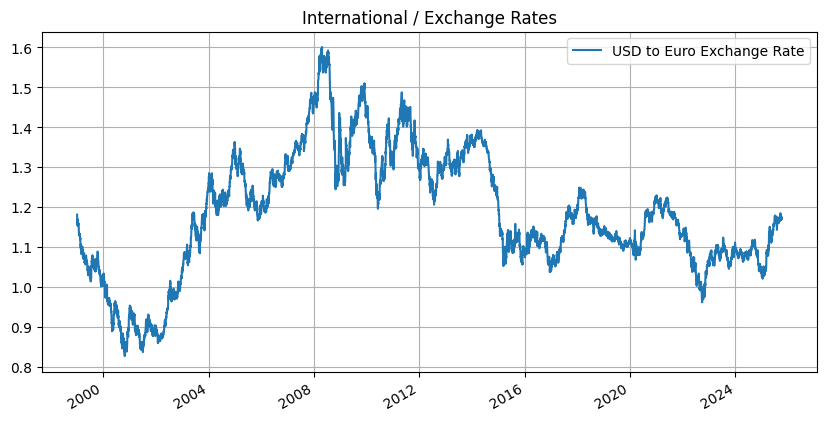

In [34]:




series = {
#'Trade-Weighted USD Index':	'DTWEXBGS',
'USD to Euro Exchange Rate':	'DEXUSEU',
#'USD to JPY Exchange Rate':	'DEXJPUS',
#'Foreign Exchange Reserves (China)':	'TRESEGUSM052N',
}
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data.dropna().plot(
    figsize=(10, 5), title="International / Exchange Rates"
)
plt.grid(True)
plt.show()

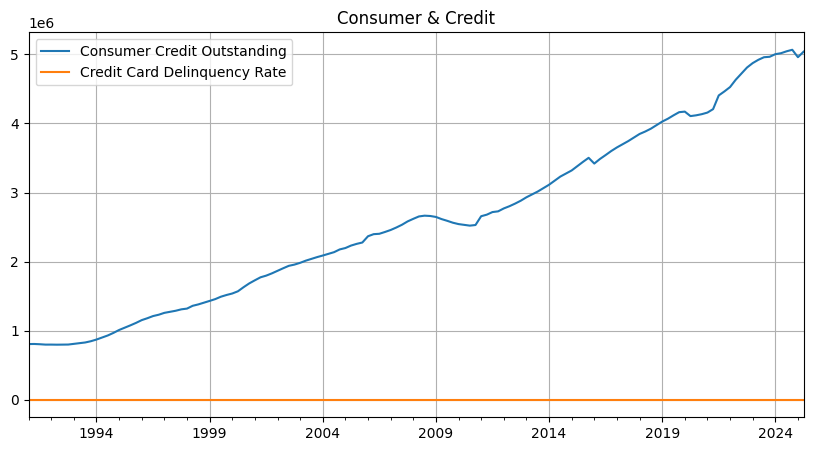

In [35]:
series = {
'Consumer Credit Outstanding':	'TOTALSL',
'Credit Card Delinquency Rate':	'DRCCLACBS',
#'Household Debt to GDP':	'HDTGDPUSQ163N',
}
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data.dropna().plot(
    figsize=(10, 5), title="Consumer & Credit"
)
plt.grid(True)
plt.show()

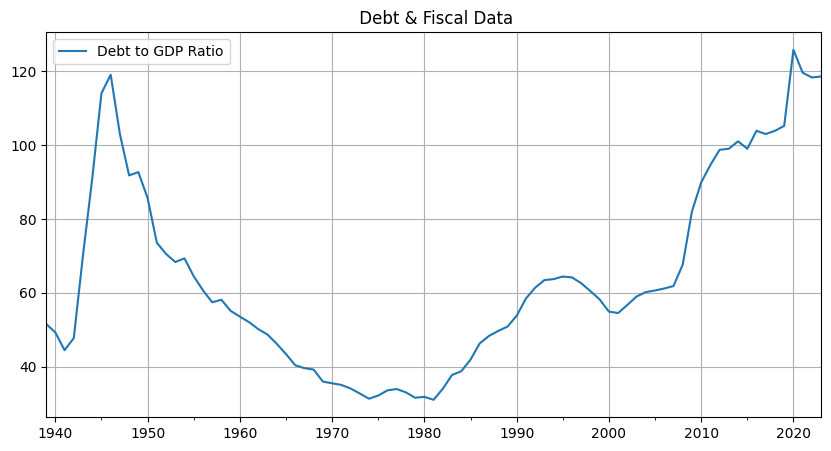

In [36]:
series = {
#'Federal Government Debt':	'GFDEBTN',
'Debt to GDP Ratio':	'GFDGDPA188S',
#'Federal Surplus/Deficit':	'MTSDS133FMS',
#'Government Spending':	'FGEXPND',
}
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data.dropna().plot(
    figsize=(10, 5), title=" Debt & Fiscal Data"
)
plt.grid(True)
plt.show()

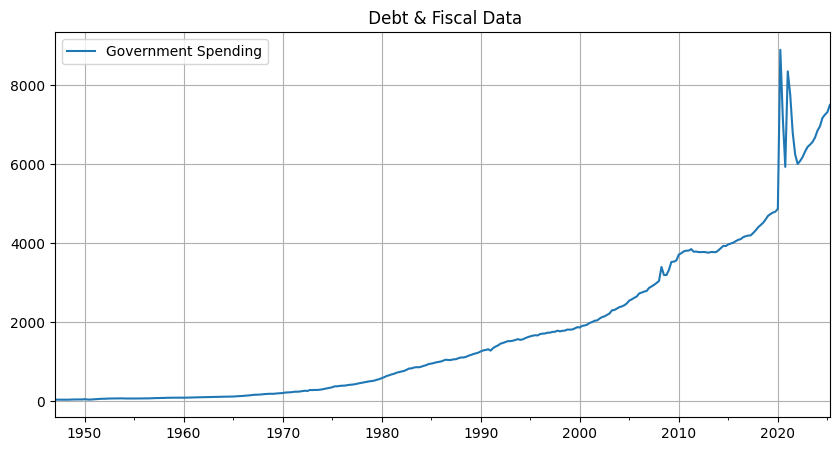

In [37]:
series = {
#'Federal Government Debt':	'GFDEBTN',
#'Debt to GDP Ratio':	'GFDGDPA188S',
#'Federal Surplus/Deficit':	'MTSDS133FMS',
'Government Spending':	'FGEXPND',
}
macro_data = pd.DataFrame({name: fred.get_series(id) for name, id in series.items()})

# Plot example: inflation and unemployment
macro_data.dropna().plot(
    figsize=(10, 5), title=" Debt & Fiscal Data"
)
plt.grid(True)
plt.show()

In [38]:
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
data = yf.download(tickers, start='2001-01-01', end='2025-01-01')["Close"]
returns = data.pct_change().dropna()

[*********************100%***********************]  4 of 4 completed

4 Failed downloads:
['GOOGL', 'MSFT', 'AAPL', 'AMZN']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


<Axes: xlabel='Date'>

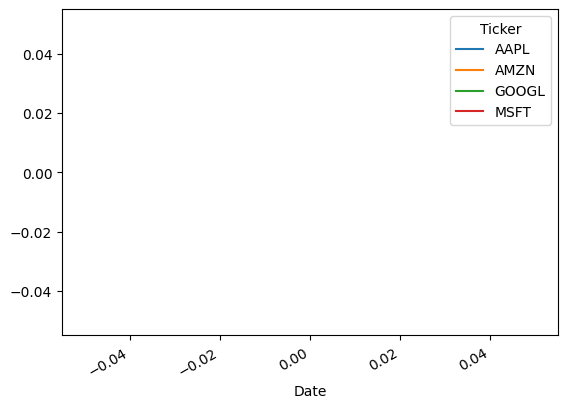

In [39]:
data.plot()

[*********************100%***********************]  4 of 4 completed

4 Failed downloads:
['IEF', 'TLT', 'BND', 'SHY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


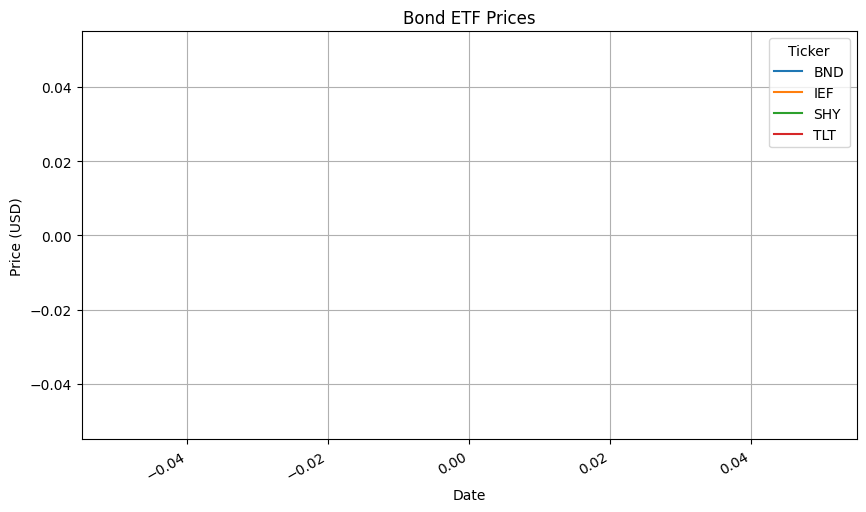

In [40]:
tickers = ['TLT', 'IEF', 'SHY', 'BND']

# Download historical data (adjust period/range as needed)
bond_data = yf.download(tickers, start="2001-01-01", end="2025-01-01")["Close"]
bond_returns = bond_data.pct_change().dropna()
month_bond = bond_data.resample("BMS").first()
bond_month_return = month_bond.pct_change().dropna()
# Plotting
bond_data.plot(figsize=(10, 6), title="Bond ETF Prices")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [41]:
returns

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,


In [42]:
returns_monthly = data.resample("BMS").first()

In [43]:
returns_monthly = returns_monthly.pct_change().dropna()

In [44]:
returns_monthly.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,


In [45]:
def calculate_returns(returns, returns_period, period):
    covariance = {}
    for i in returns_period.index:
        rtd_index = returns.index
        if period =="month":
            mask = (rtd_index.month == i.month) & (rtd_index.year == i.year)
        elif period == "week":
            mask = mask = ((rtd_index.isocalendar().week == i.isocalendar().week) &(rtd_index.isocalendar().year == i.isocalendar().year))
        elif period == "quarter":
            mask = (rtd_index.quarter == i.quarter) & (rtd_index.year == i.year)
        covariance[i] = returns[mask].cov()
    portfolio_returns = {}
    portfolio_volatility = {}
    portfolio_weights = {}
    for date in covariance.keys():
        cov = covariance[date]
        for k in range(10000):
            weights = np.random.random(returns.shape[1])
            weights = weights/np.sum(weights)
            returnss = np.dot(weights, returns_period.loc[date])
            volatility = np.sqrt(np.dot(weights.T,np.dot(cov, weights)))
            portfolio_returns.setdefault(date,[]).append(returnss)
            portfolio_volatility.setdefault(date,[]).append(volatility)
            portfolio_weights.setdefault(date,[]).append(weights)
    sharpe_ratio = {}
    max_sharpe = {}
    vols = {}
    min_vol = {}
    for date in covariance.keys():
        for i, (ret, vol) in enumerate(zip(portfolio_returns[date], portfolio_volatility[date])):
            sharpe_ratio.setdefault(date, []).append(ret / vol)
            vols.setdefault(date, []).append(vol)
        max_sharpe[date] = np.argmax(sharpe_ratio[date])
        min_vol[date] = np.argmin(vols[date])
    dates = sorted(covariance.keys())

    strategy_returns = []
    strategy_returns2 = []

    for i in range(len(dates) - 1):
        current_date = dates[i]
        next_date = dates[i + 1]

        weights = portfolio_weights[current_date][min_vol[current_date]]
        weights2 = portfolio_weights[current_date][max_sharpe[current_date]]

        returns_next = returns_period.loc[next_date] 

        port_return = np.dot(weights, returns_next)
        port_return2 = np.dot(weights2, returns_next)
        strategy_returns.append(port_return)
        strategy_returns2.append(port_return2)

    strategy_returns = pd.Series(strategy_returns, index=dates[1:])
    strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

    cumulative_returns = (1 + strategy_returns).cumprod()

    total_return = cumulative_returns.iloc[-1] - 1

    cumulative_returns2 = (1 + strategy_returns2).cumprod()

    total_return2 = cumulative_returns2.iloc[-1] - 1

    print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
    print(f"Total return from strategy of max sharpe: {total_return2:.2%}")
    #
    # including tax costs
    #
    dates = sorted(covariance.keys())

    strategy_returns = []
    strategy_returns2 = []

    for i in range(len(dates) - 1):
        current_date = dates[i]
        next_date = dates[i + 1]

        weights = portfolio_weights[current_date][min_vol[current_date]]
        weights2 = portfolio_weights[current_date][max_sharpe[current_date]]
        returns_next = returns_period.loc[next_date] 
        returns_next = np.where(returns_next>0.0, returns_next*0.79, returns_next)

        port_return = np.dot(weights, returns_next)
        port_return2 = np.dot(weights2, returns_next)
        strategy_returns.append(port_return)
        strategy_returns2.append(port_return2)

    strategy_returns = pd.Series(strategy_returns, index=dates[1:])
    strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

    cumulative_returns = (1 + strategy_returns).cumprod()

    total_return = cumulative_returns.iloc[-1] - 1

    cumulative_returns2 = (1 + strategy_returns2).cumprod()

    total_return2 = cumulative_returns2.iloc[-1] - 1

    print(f"Total return from strategy of minimum volatility taking taxes into account: {total_return:.2%}")
    print(f"Total return from strategy of max sharpe taking taxes into account: {total_return2:.2%}")
    return strategy_returns, strategy_returns2, max_sharpe, min_vol

In [46]:
covariance = {}
for i in returns_monthly.index:
    rtd_index = returns.index
    mask = (rtd_index.month == i.month) & (rtd_index.year == i.year)
    covariance[i] = returns[mask].cov()

In [47]:
portfolio_returns = {}
portfolio_volatility = {}
portfolio_weights = {}
for date in covariance.keys():
    cov = covariance[date]
    for k in range(10000):
        weights = np.random.random(4)
        weights = weights/np.sum(weights)
        returnss = np.dot(weights, returns_monthly.loc[date])
        volatility = np.sqrt(np.dot(weights.T,np.dot(cov, weights)))
        portfolio_returns.setdefault(date,[]).append(returnss)
        portfolio_volatility.setdefault(date,[]).append(volatility)
        portfolio_weights.setdefault(date,[]).append(weights)




In [48]:
sharpe_ratio = {}
max_sharpe = {}
vols = {}
min_vol = {}
for date in covariance.keys():
    for i, (ret, vol) in enumerate(zip(portfolio_returns[date], portfolio_volatility[date])):
        sharpe_ratio.setdefault(date, []).append(ret / vol)
        vols.setdefault(date, []).append(vol)
    max_sharpe[date] = np.argmax(sharpe_ratio[date])
    min_vol[date] = np.argmin(vols[date])

print(max_sharpe)

{}


In [49]:
apple = []
microsoft = []
google = []
amazon = []
apple2 = []
microsoft2 = []
google2 = []
amazon2 = []
for date in covariance.keys():
    apple.append(portfolio_weights[date][max_sharpe[date]][0])
    microsoft.append(portfolio_weights[date][max_sharpe[date]][1])
    google.append(portfolio_weights[date][max_sharpe[date]][2])
    amazon.append(portfolio_weights[date][max_sharpe[date]][3])
    apple2.append(portfolio_weights[date][min_vol[date]][0])
    microsoft2.append(portfolio_weights[date][min_vol[date]][1])
    google2.append(portfolio_weights[date][min_vol[date]][2])
    amazon2.append(portfolio_weights[date][min_vol[date]][3])
print(np.mean(apple2))
print(np.mean(microsoft2))
print(np.mean(google2))
print(np.mean(amazon2))
print(np.mean(apple) + np.mean(microsoft) + np.mean(google)+ np.mean(amazon))
avg_weights = [np.mean(apple), np.mean(microsoft),np.mean(google), np.mean(amazon) ]
avg_weights2 = [np.mean(apple2), np.mean(microsoft2),np.mean(google2), np.mean(amazon2) ]

nan
nan
nan
nan
nan


/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [50]:

cumulative_returns = (1 + returns_monthly).cumprod()

In [51]:
cumulative_returns.tail()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,


In [52]:
cash = 10


asset_total_returns = cumulative_returns.iloc[-1] - 1  


average_returns  = np.sum(avg_weights  * asset_total_returns)
average_returns2 = np.sum(avg_weights2 * asset_total_returns)


final_value1 = cash * (1 + average_returns)
final_value2 = cash * (1 + average_returns2)

print(f"Strategy 1 (Max Sharpe):     Final Value = ${final_value1:.2f} | Return = {average_returns:.2%}")
print(f"Strategy 2 (Min Volatility): Final Value = ${final_value2:.2f} | Return = {average_returns2:.2%}")
print("Individual asset returns:",  asset_total_returns*100)

IndexError: single positional indexer is out-of-bounds

In [27]:
dates = sorted(covariance.keys())

strategy_returns = []
strategy_returns2 = []

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    weights = portfolio_weights[current_date][min_vol[current_date]]
    weights2 = portfolio_weights[current_date][max_sharpe[current_date]]

    returns_next = returns_monthly.loc[next_date] 

    port_return = np.dot(weights, returns_next)
    port_return2 = np.dot(weights2, returns_next)
    strategy_returns.append(port_return)
    strategy_returns2.append(port_return2)

strategy_returns = pd.Series(strategy_returns, index=dates[1:])
strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

cumulative_returns = (1 + strategy_returns).cumprod()

total_return = cumulative_returns.iloc[-1] - 1

cumulative_returns2 = (1 + strategy_returns2).cumprod()

total_return2 = cumulative_returns2.iloc[-1] - 1

print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
print(f"Total return from strategy of max sharpe: {total_return2:.2%}")

Total return from strategy of minimum volatility: 6615.20%
Total return from strategy of max sharpe: 15228.48%


In [28]:
#
# including tax costs
#
dates = sorted(covariance.keys())

strategy_returns = []
strategy_returns2 = []

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    weights = portfolio_weights[current_date][min_vol[current_date]]
    weights2 = portfolio_weights[current_date][max_sharpe[current_date]]
    returns_next = returns_monthly.loc[next_date] 
    returns_next = np.where(returns_next>0.0, returns_next*0.79, returns_next)

    port_return = np.dot(weights, returns_next)
    port_return2 = np.dot(weights2, returns_next)
    strategy_returns.append(port_return)
    strategy_returns2.append(port_return2)

strategy_returns = pd.Series(strategy_returns, index=dates[1:])
strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

cumulative_returns = (1 + strategy_returns).cumprod()

total_return = cumulative_returns.iloc[-1] - 1

cumulative_returns2 = (1 + strategy_returns2).cumprod()

total_return2 = cumulative_returns2.iloc[-1] - 1

print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
print(f"Total return from strategy of max sharpe: {total_return2:.2%}")

Total return from strategy of minimum volatility: 917.85%
Total return from strategy of max sharpe: 1666.13%


In [29]:
print(100*0.79*(1+returns).cumprod().iloc[-1]-1)

Ticker
AAPL     42764.621632
AMZN      8972.238586
GOOGL     5976.239182
MSFT      1976.790381
Name: 2024-12-31 00:00:00, dtype: float64


<Axes: xlabel='Ticker', ylabel='Ticker'>

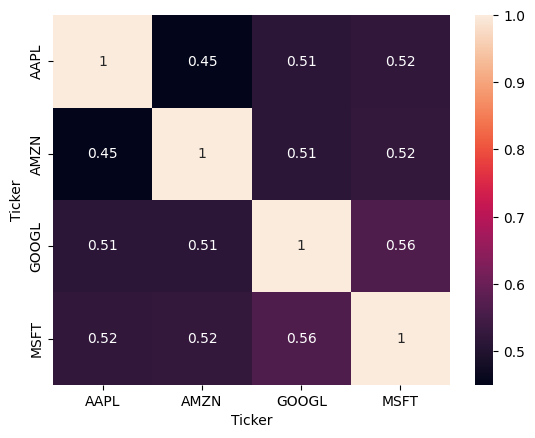

In [30]:
import seaborn as sns

sns.heatmap(returns.corr(), annot=True)

5126
5126


<Axes: xlabel='Ticker', ylabel='Ticker'>

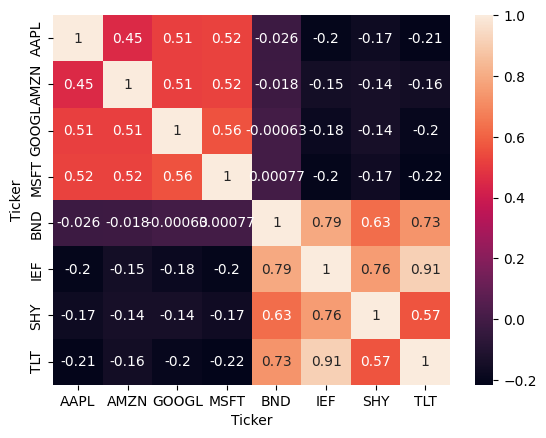

In [31]:
all_returns = pd.concat([returns, bond_returns], axis=1)
print(len(all_returns))
all_month = pd.concat([returns_monthly, bond_month_return], axis = 1).dropna()
all_returns.dropna()
print(len(all_returns))
sns.heatmap(all_returns.corr(), annot=True)

6217


<Axes: xlabel='Ticker', ylabel='Ticker'>

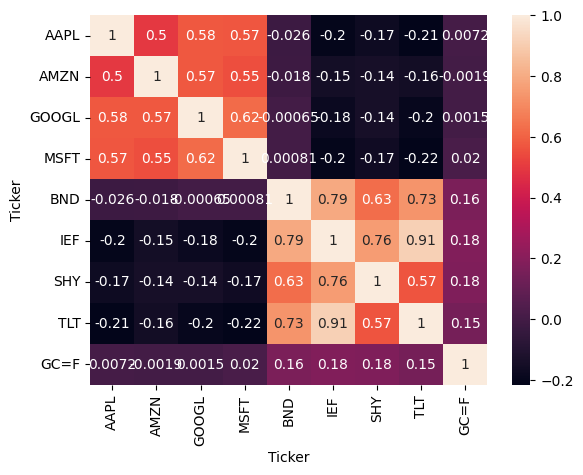

In [32]:
gold_ret = gold_yahoo.pct_change().dropna()
gold_month = gold_yahoo.resample("BMS").first()
gold_ret_month = gold_month.pct_change().dropna()
print(len(gold_ret))

all_returns = pd.concat([all_returns, gold_ret], axis = 1)
all_month = pd.concat([all_month, gold_ret_month], axis = 1)
all_returns =all_returns.dropna()
sns.heatmap(all_returns.corr(), annot=True)

In [33]:
all_month = all_month.dropna()
print(len(all_month), len(all_returns))

212 4460


In [80]:
calculate_returns(all_returns, all_month, "month")

Total return from strategy of minimum volatility: 295.34%
Total return from strategy of max sharpe: 719.91%
Total return from strategy of minimum volatility taking taxes into account: 115.28%
Total return from strategy of max sharpe taking taxes into account: 206.96%


(2007-06-01   -0.003945
 2007-07-02    0.002218
 2007-08-01    0.007119
 2007-09-03    0.014284
 2007-10-01    0.031052
                 ...   
 2024-08-01    0.015272
 2024-09-02    0.003187
 2024-10-01    0.016105
 2024-11-01   -0.018295
 2024-12-02    0.009014
 Length: 211, dtype: float64,
 2007-06-01    0.029654
 2007-07-02    0.016284
 2007-08-01    0.003680
 2007-09-03    0.014284
 2007-10-01    0.033006
                 ...   
 2024-08-01   -0.036821
 2024-09-02    0.013003
 2024-10-01    0.016242
 2024-11-01   -0.001867
 2024-12-02    0.013772
 Length: 211, dtype: float64,
 {Timestamp('2007-05-01 00:00:00'): np.int64(6683),
  Timestamp('2007-06-01 00:00:00'): np.int64(8423),
  Timestamp('2007-07-02 00:00:00'): np.int64(1795),
  Timestamp('2007-08-01 00:00:00'): np.int64(8454),
  Timestamp('2007-09-03 00:00:00'): np.int64(575),
  Timestamp('2007-10-01 00:00:00'): np.int64(1862),
  Timestamp('2007-11-01 00:00:00'): np.int64(1892),
  Timestamp('2007-12-03 00:00:00'): np.int64(3210

In [34]:
covariance = {}
for i in all_month.index:
    rtd_index = all_returns.index
    mask = (rtd_index.month == i.month) & (rtd_index.year == i.year)
    covariance[i] = all_returns[mask].cov()


In [35]:
portfolio_returns = {}
portfolio_volatility = {}
portfolio_weights = {}
for date in covariance.keys():
    cov = covariance[date]
    for k in range(10000):
        weights = np.random.random(9)
        weights = weights/np.sum(weights)
        returnss = np.dot(weights, all_month.loc[date])
        volatility = np.sqrt(np.dot(weights.T,np.dot(cov, weights)))
        portfolio_returns.setdefault(date,[]).append(returnss)
        portfolio_volatility.setdefault(date,[]).append(volatility)
        portfolio_weights.setdefault(date,[]).append(weights)

In [36]:
sharpe_ratio = {}
max_sharpe = {}
vols = {}
min_vol = {}
for date in covariance.keys():
    for i, (ret, vol) in enumerate(zip(portfolio_returns[date], portfolio_volatility[date])):
        sharpe_ratio.setdefault(date, []).append(ret / vol)
        vols.setdefault(date, []).append(vol)
    max_sharpe[date] = np.argmax(sharpe_ratio[date])
    min_vol[date] = np.argmin(vols[date])

print(max_sharpe, min_vol)

{Timestamp('2007-05-01 00:00:00'): np.int64(7045), Timestamp('2007-06-01 00:00:00'): np.int64(5315), Timestamp('2007-07-02 00:00:00'): np.int64(6712), Timestamp('2007-08-01 00:00:00'): np.int64(6340), Timestamp('2007-09-03 00:00:00'): np.int64(5322), Timestamp('2007-10-01 00:00:00'): np.int64(1688), Timestamp('2007-11-01 00:00:00'): np.int64(292), Timestamp('2007-12-03 00:00:00'): np.int64(3976), Timestamp('2008-01-01 00:00:00'): np.int64(2195), Timestamp('2008-02-01 00:00:00'): np.int64(4737), Timestamp('2008-03-03 00:00:00'): np.int64(7580), Timestamp('2008-04-01 00:00:00'): np.int64(7446), Timestamp('2008-05-01 00:00:00'): np.int64(8184), Timestamp('2008-06-02 00:00:00'): np.int64(5519), Timestamp('2008-07-01 00:00:00'): np.int64(6680), Timestamp('2008-08-01 00:00:00'): np.int64(1865), Timestamp('2008-09-01 00:00:00'): np.int64(4368), Timestamp('2008-10-01 00:00:00'): np.int64(9646), Timestamp('2008-11-03 00:00:00'): np.int64(4284), Timestamp('2008-12-01 00:00:00'): np.int64(9806), 

In [37]:
apple = []
microsoft = []
google = []
amazon = []
bnd = []
ief = []
shy = []
tlt = []
gol = []
apple2 = []
microsoft2 = []
google2 = []
amazon2 = []
bnd2 = []
ief2 = []
shy2 = []
tlt2 = []
gol2 = []
for date in covariance.keys():
    apple.append(portfolio_weights[date][max_sharpe[date]][0])
    microsoft.append(portfolio_weights[date][max_sharpe[date]][3])
    google.append(portfolio_weights[date][max_sharpe[date]][2])
    amazon.append(portfolio_weights[date][max_sharpe[date]][1])
    bnd.append(portfolio_weights[date][max_sharpe[date]][4])
    ief.append(portfolio_weights[date][max_sharpe[date]][5])
    shy.append(portfolio_weights[date][max_sharpe[date]][6])
    tlt.append(portfolio_weights[date][max_sharpe[date]][7])
    gol.append(portfolio_weights[date][max_sharpe[date]][8])
    apple2.append(portfolio_weights[date][min_vol[date]][0])
    microsoft2.append(portfolio_weights[date][min_vol[date]][3])
    google2.append(portfolio_weights[date][min_vol[date]][2])
    amazon2.append(portfolio_weights[date][min_vol[date]][1])
    bnd2.append(portfolio_weights[date][min_vol[date]][4])
    ief2.append(portfolio_weights[date][min_vol[date]][5])
    shy2.append(portfolio_weights[date][min_vol[date]][6])
    tlt2.append(portfolio_weights[date][min_vol[date]][7])
    gol2.append(portfolio_weights[date][min_vol[date]][8])
print(np.mean(gol), np.mean(gol2))
print(np.mean(microsoft2))
print(np.mean(google2))
print(np.mean(amazon2))
print(np.mean(apple) + np.mean(microsoft) + np.mean(google)+ np.mean(amazon))
avg_weights = [np.mean(apple), np.mean(amazon),np.mean(google), np.mean(microsoft), np.mean(bnd), np.mean(ief), np.mean(shy), np.mean(tlt), np.mean(gol) ]
avg_weights2 = [np.mean(apple2), np.mean(amazon2),np.mean(google2), np.mean(microsoft2) , np.mean(bnd2), np.mean(ief2), np.mean(shy2), np.mean(tlt2), np.mean(gol2) ]

0.10809634710233254 0.08514293124374364
0.047378932079761994
0.035786578085350164
0.02913868036819944
0.3640985079759048


In [38]:
cumulative_returns = (1 + all_month).cumprod()
cumulative_returns.tail()
var_95_all_assets = np.percentile(all_month, 5, axis=0)
print(var_95_all_assets)

[-0.11505893 -0.11851299 -0.11486045 -0.1054118  -0.01683973 -0.03168498
 -0.00434323 -0.06759457 -0.06856798]


In [39]:
cash = 10


asset_total_returns = cumulative_returns.iloc[-1] - 1  


average_returns  = np.sum(avg_weights  * asset_total_returns)
average_returns2 = np.sum(avg_weights2 * asset_total_returns)


final_value1 = cash * (1 + average_returns)
final_value2 = cash * (1 + average_returns2)

print(f"Strategy 1 (Max Sharpe):     Final Value = ${final_value1:.2f} | Return = {average_returns:.2%}")
print(f"Strategy 2 (Min Volatility): Final Value = ${final_value2:.2f} | Return = {average_returns2:.2%}")
print("Individual asset returns:",  asset_total_returns)

Strategy 1 (Max Sharpe):     Final Value = $211.54 | Return = 2015.39%
Strategy 2 (Min Volatility): Final Value = $98.00 | Return = 880.05%
Individual asset returns: Ticker
AAPL      83.919906
AMZN     103.260275
GOOGL     13.982028
MSFT      20.727443
BND        0.679923
IEF        0.751889
SHY        0.341281
TLT        0.806289
GC=F       2.958089
Name: 2024-12-02 00:00:00, dtype: float64


In [40]:
dates = sorted(covariance.keys())

strategy_returns = []
strategy_returns2 = []

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    weights = portfolio_weights[current_date][min_vol[current_date]]
    weights2 = portfolio_weights[current_date][max_sharpe[current_date]]

    returns_next = all_month.loc[next_date] 

    port_return = np.dot(weights, returns_next)
    port_return2 = np.dot(weights2, returns_next)
    strategy_returns.append(port_return)
    strategy_returns2.append(port_return2)

strategy_returns = pd.Series(strategy_returns, index=dates[1:])
strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

cumulative_returns = (1 + strategy_returns).cumprod()

total_return = cumulative_returns.iloc[-1] - 1

cumulative_returns2 = (1 + strategy_returns2).cumprod()

total_return2 = cumulative_returns2.iloc[-1] - 1

print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
print(f"Total return from strategy of max sharpe: {total_return2:.2%}")
print(np.percentile(strategy_returns,0.05), np.percentile(strategy_returns2,0.05))
print(np.mean(strategy_returns),np.mean(strategy_returns2))

Total return from strategy of minimum volatility: 276.54%
Total return from strategy of max sharpe: 653.82%
-0.038869181286342355 -0.11970424386835211
0.0064329195850474025 0.010089132222353197


In [41]:
dates = sorted(covariance.keys())

strategy_returns = []
strategy_returns2 = []

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    weights = portfolio_weights[current_date][min_vol[current_date]]
    weights2 = portfolio_weights[current_date][max_sharpe[current_date]]
    returns_next = all_month.loc[next_date] 
    returns_next = np.where(returns_next>0.0, returns_next*0.79, returns_next)

    port_return = np.dot(weights, returns_next)
    port_return2 = np.dot(weights2, returns_next)
    strategy_returns.append(port_return)
    strategy_returns2.append(port_return2)

strategy_returns = pd.Series(strategy_returns, index=dates[1:])
strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

cumulative_returns = (1 + strategy_returns).cumprod()

total_return = cumulative_returns.iloc[-1] - 1

cumulative_returns2 = (1 + strategy_returns2).cumprod()

total_return2 = cumulative_returns2.iloc[-1] - 1

print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
print(f"Total return from strategy of max sharpe: {total_return2:.2%}")

Total return from strategy of minimum volatility: 105.85%
Total return from strategy of max sharpe: 183.70%


In [42]:
tax_rate = 0.21  # e.g., 21% capital gains tax

strategy_returns = []
strategy_returns2 = []

tax_savings = []
tax_savings2 = []

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    weights = portfolio_weights[current_date][min_vol[current_date]]
    weights2 = portfolio_weights[current_date][max_sharpe[current_date]]
    returns_next = all_month.loc[next_date]

    # Apply tax on profits: 21% tax on positive returns, 21% benefit on losses
    # Assuming 79% of gains are retained (already in your code)
    returns_next = np.where(returns_next > 0.0, returns_next * (1 - tax_rate), returns_next)

    # Calculate returns
    port_return = np.dot(weights, returns_next)
    port_return2 = np.dot(weights2, returns_next)

    # Add tax benefit from loss
    tax_credit = 0.0
    tax_credit2 = 0.0
    if port_return < 0:
        tax_credit = -port_return * tax_rate  # tax benefit
    if port_return2 < 0:
        tax_credit2 = -port_return2 * tax_rate

    # Final return = return + tax deduction from loss
    strategy_returns.append(port_return + tax_credit)
    strategy_returns2.append(port_return2 + tax_credit2)

    tax_savings.append(tax_credit)
    tax_savings2.append(tax_credit2)

# Convert to Series
strategy_returns = pd.Series(strategy_returns, index=dates[1:])
strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

# Cumulative returns
cumulative_returns = (1 + strategy_returns).cumprod()
cumulative_returns2 = (1 + strategy_returns2).cumprod()

# Total return
total_return = cumulative_returns.iloc[-1] - 1
total_return2 = cumulative_returns2.iloc[-1] - 1

print(f"Total return from strategy of minimum volatility (after tax-loss benefits): {total_return:.2%}")
print(f"Total return from strategy of max sharpe (after tax-loss benefits): {total_return2:.2%}")


Total return from strategy of minimum volatility (after tax-loss benefits): 146.25%
Total return from strategy of max sharpe (after tax-loss benefits): 300.34%


-0.03084567745234192
-0.09738113478307463


(array([ 2.,  5.,  4.,  4.,  6., 17., 22., 23., 28., 23., 30., 18., 14.,
         5.,  5.,  2.,  1.,  0.,  1.,  1.]),
 array([-0.03086744, -0.02687315, -0.02287886, -0.01888457, -0.01489028,
        -0.01089598, -0.00690169, -0.0029074 ,  0.00108689,  0.00508118,
         0.00907547,  0.01306976,  0.01706405,  0.02105834,  0.02505263,
         0.02904692,  0.03304122,  0.03703551,  0.0410298 ,  0.04502409,
         0.04901838]),
 <BarContainer object of 20 artists>)

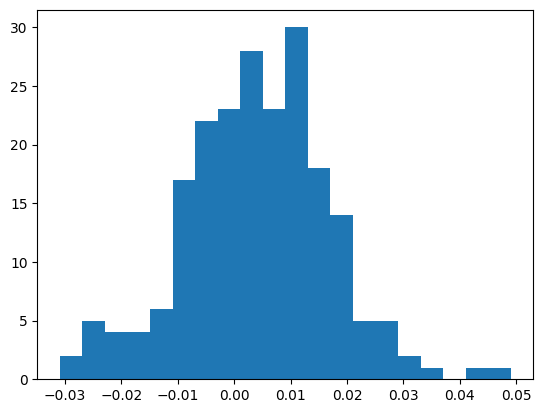

In [43]:
print(np.percentile(strategy_returns, 0.01))
print(np.percentile(strategy_returns2, 0.01))
plt.hist(strategy_returns, bins = 20)

(np.float64(0.004361880930187729), np.float64(0.012807667971492012))
-0.030867439855412453


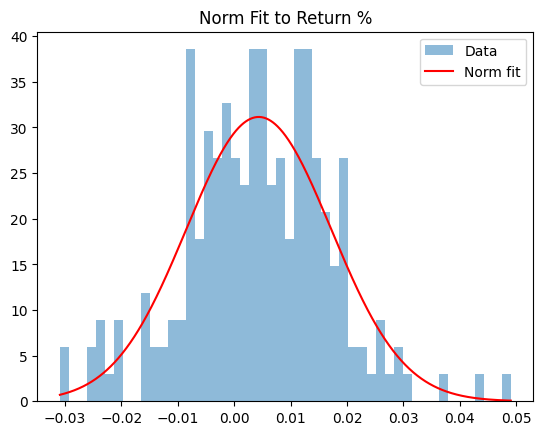

In [44]:
params_norm = norm.fit(strategy_returns)
print(params_norm)
print(min(strategy_returns))

x = np.linspace(strategy_returns.min(), strategy_returns.max(), 1000)
pdf = norm.pdf(x, *params_norm)

plt.hist(strategy_returns, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Norm fit")
plt.legend()
plt.title("Norm Fit to Return %")
plt.show()

(np.float64(0.8053760015042424), np.float64(-0.007166704334818843), np.float64(0.02820340693369939))
-0.09808483031484375


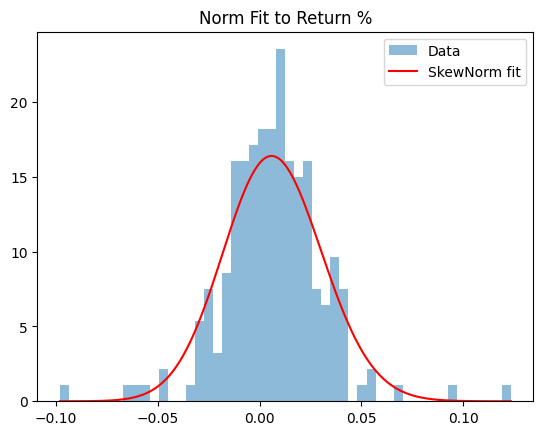

In [45]:
params_norm = skewnorm.fit(strategy_returns2)
print(params_norm)
print(min(strategy_returns2))

x = np.linspace(strategy_returns2.min(), strategy_returns2.max(), 1000)
pdf = skewnorm.pdf(x, *params_norm)

plt.hist(strategy_returns2, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="SkewNorm fit")
plt.legend()
plt.title("Norm Fit to Return %")
plt.show()

In [46]:
tips_data = yf.download(["TIP", "VTIP", "LTPZ"], start="2001-01-01", end="2024-12-31")["Close"]
tips_data.dropna()

[*********************100%***********************]  3 of 3 completed


Ticker,LTPZ,TIP,VTIP
Date,,,
2012-10-16,49.093895,89.025429,37.738297
2012-10-17,48.802895,88.762032,37.730724
2012-10-18,48.913780,88.754715,37.708027
2012-10-19,49.474941,89.054733,37.768555
2012-10-22,49.287899,88.908432,37.745838
...,...,...,...
2024-12-23,50.385437,103.755798,47.185886
2024-12-24,50.713547,103.989830,47.214218
2024-12-26,50.723202,103.989830,47.233749


In [47]:
from arch import arch_model

In [48]:
basic_gm = arch_model(returns["AAPL"], p = 1, q= 1, mean="constant", vol="GARCH", dist="normal")

In [49]:
gm_result = basic_gm.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4581785184.023783
Iteration:      2,   Func. Count:     18,   Neg. LLF: -13189.653893460389
Optimization terminated successfully    (Exit mode 0)
            Current function value: -13189.653924128801
            Iterations: 6
            Function evaluations: 18
            Gradient evaluations: 2


/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004158. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [50]:
print(gm_result.params, gm_result.summary)

mu          0.001816
omega       0.000008
alpha[1]    0.050000
beta[1]     0.930000
Name: params, dtype: float64 <bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                13189.7
Distribution:                  Normal   AIC:                          -26371.3
Method:            Maximum Likelihood   BIC:                          -26345.1
                                        No. Observations:                 5126
Date:                Sat, Oct 11 2025   Df Residuals:                     5125
Time:                        15:30:27   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|    

In [51]:
gm_result.tvalues

mu             23.761857
omega       22956.369906
alpha[1]        7.530456
beta[1]       165.533048
Name: tvalues, dtype: float64

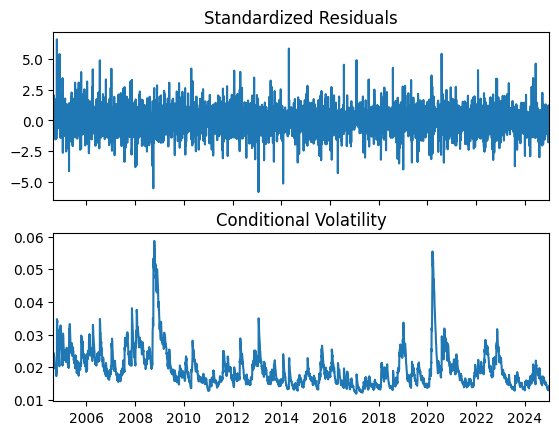

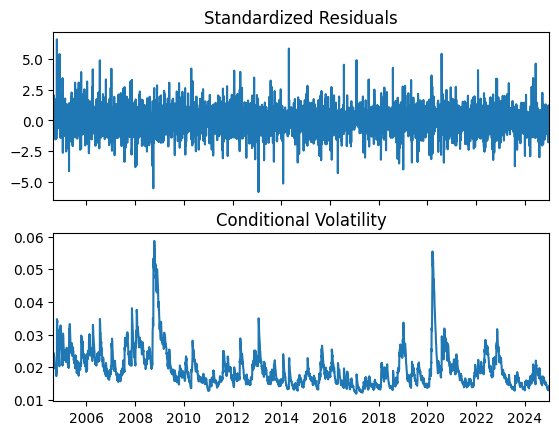

In [52]:
gm_result.plot()

In [53]:
gm_std_resid = gm_result.resid/gm_result.conditional_volatility

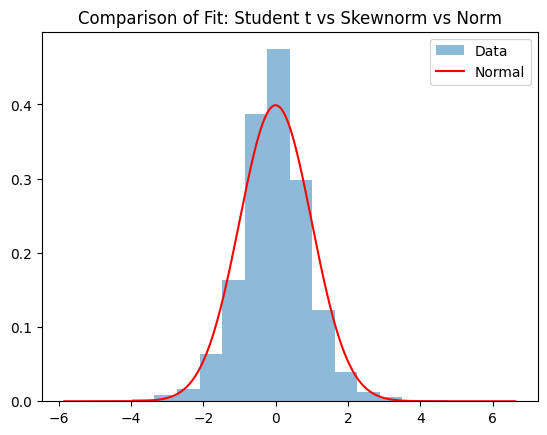

In [54]:

plt.hist(gm_std_resid, bins = 20,density=True, alpha=0.5, label="Data")
x = np.linspace(gm_std_resid.min(), gm_std_resid.max(), 1000)
pdf_norm = norm.pdf(x, loc=0, scale=1)
plt.plot(x, pdf_norm, 'r-', label="Normal")
plt.legend()
plt.title("Comparison of Fit: Student t vs Skewnorm vs Norm")
plt.show()

In [55]:
from scipy.stats import entropy
import numpy as np

hist, bin_edges = np.histogram(gm_std_resid, bins=50, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

pdf_norm = norm.pdf(bin_centers, loc=0, scale=1)

epsilon = 1e-10
kl_divergence = entropy(hist + epsilon, pdf_norm + epsilon)
print(f"KL divergence (Normal fit): {kl_divergence}")

KL divergence (Normal fit): 0.05075185692808133


In [56]:
basic_gm = arch_model(returns["AAPL"], p = 1, q= 1, mean="constant", vol="GARCH", dist="t")
gm_result = basic_gm.fit()
print(gm_result.params, gm_result.summary)

Iteration:      1,   Func. Count:      7,   Neg. LLF: 259333.22823433566
Iteration:      2,   Func. Count:     23,   Neg. LLF: 2012335.3119946818
Iteration:      3,   Func. Count:     39,   Neg. LLF: 69182.54459367404
Iteration:      4,   Func. Count:     45,   Neg. LLF: 74476.52240711122
Iteration:      5,   Func. Count:     54,   Neg. LLF: 62421.813009387224
Iteration:      6,   Func. Count:     60,   Neg. LLF: 61976.87664320248
Iteration:      7,   Func. Count:     66,   Neg. LLF: 59547.8481637769
Iteration:      8,   Func. Count:     72,   Neg. LLF: 30784.544147174038
Iteration:      9,   Func. Count:     78,   Neg. LLF: 102349.23482925532
Iteration:     10,   Func. Count:     89,   Neg. LLF: 30237.879925547244
Iteration:     11,   Func. Count:    100,   Neg. LLF: 20994.51645267357
Iteration:     12,   Func. Count:    109,   Neg. LLF: 49112463.22052276
Iteration:     13,   Func. Count:    125,   Neg. LLF: 65427.732224762425
Iteration:     14,   Func. Count:    136,   Neg. LLF: 4846

/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004158. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [57]:
print(gm_result.params, gm_result.summary)

mu         -29.018184
omega        0.004158
alpha[1]     0.000004
beta[1]      0.070713
nu           4.311893
Name: params, dtype: float64 <bound method ARCHModelResult.summary of                         Constant Mean - GARCH Model Results                         
Dep. Variable:                         AAPL   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -136532.
Distribution:      Standardized Student's t   AIC:                           273075.
Method:                  Maximum Likelihood   BIC:                           273108.
                                              No. Observations:                 5126
Date:                      Sat, Oct 11 2025   Df Residuals:                     5125
Time:                              15:30:27   Df Model:                            1
                               Mean Model              

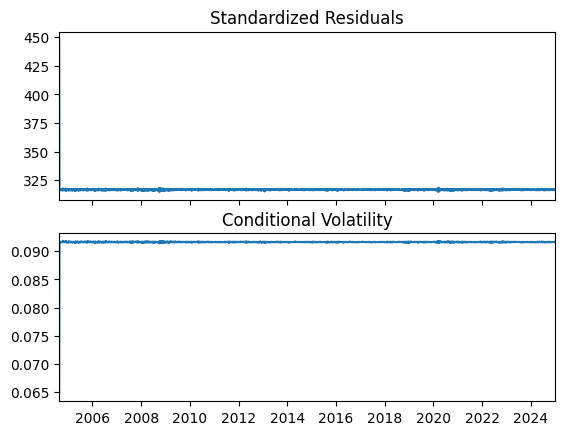

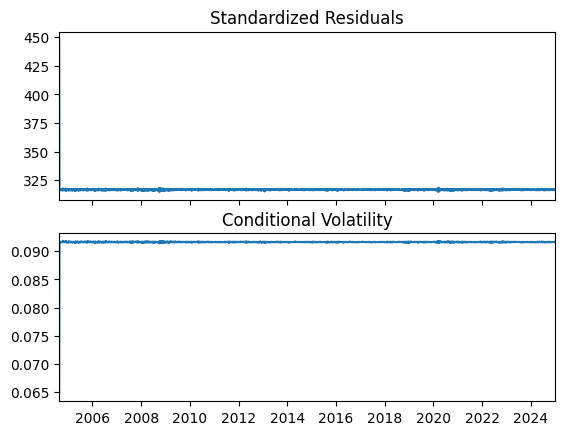

In [58]:
gm_result.plot()

In [59]:
gm_std_resid = gm_result.resid/gm_result.conditional_volatility

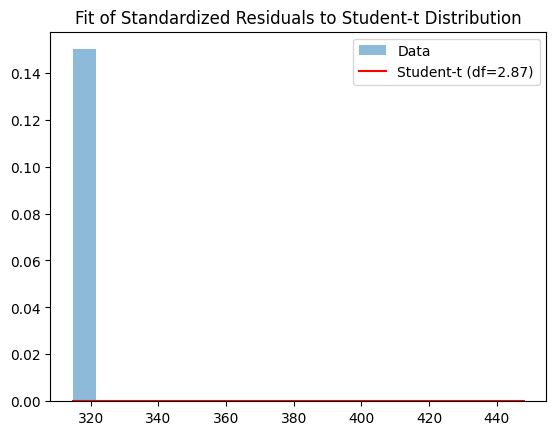

In [60]:

gm_std_resid = gm_result.resid / gm_result.conditional_volatility

# Degrees of freedom from your fitted model
df = 2.874986

plt.hist(gm_std_resid, bins=20, density=True, alpha=0.5, label="Data")

x = np.linspace(gm_std_resid.min(), gm_std_resid.max(), 1000)

# Student-t PDF with estimated degrees of freedom
pdf_t = t.pdf(x, df=df, loc=0, scale=1)

plt.plot(x, pdf_t, 'r-', label=f"Student-t (df={df:.2f})")

plt.legend()
plt.title("Fit of Standardized Residuals to Student-t Distribution")
plt.show()

In [61]:
hist, bin_edges = np.histogram(gm_std_resid, bins=50, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

pdf_t = t.pdf(bin_centers, df=df, loc=0, scale=1)

epsilon = 1e-10
kl_divergence = entropy(hist + epsilon, pdf_t + epsilon)
print(f"KL divergence (Student t fit): {kl_divergence}")

KL divergence (Student t fit): 3.34546310417248


In [62]:
returns_quarterly = data.resample("Q").first()

/var/folders/6g/8lpphcyj6zz6mrxswq4gltjr0000gn/T/ipykernel_902/1162829230.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  returns_quarterly = data.resample("Q").first()


In [63]:
returns_quarterly = returns_quarterly.pct_change().dropna()

In [64]:
returns_quarterly.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2004-12-31,0.197213,-0.230023,0.321308,-0.010362
2005-03-31,0.636670,0.100074,0.528964,0.054967
2005-06-30,0.292146,-0.236074,-0.111835,-0.095197
2005-09-30,-0.107361,-0.032343,0.617696,0.027710
2005-12-31,0.491507,0.398055,0.094180,0.035032


In [65]:
covariance = {}


# Loop over each quarter from the quarterly index
for i in returns_quarterly.index:
    rtd_index = returns.index
    mask = (rtd_index.quarter == i.quarter) & (rtd_index.year == i.year)
    covariance[i] = returns[mask].cov()


In [66]:
covariance

{Timestamp('2004-12-31 00:00:00'): Ticker      AAPL      AMZN     GOOGL      MSFT
 Ticker                                        
 AAPL    0.000878  0.000009  0.000002  0.000020
 AMZN    0.000009  0.000705 -0.000153  0.000092
 GOOGL   0.000002 -0.000153  0.001241 -0.000101
 MSFT    0.000020  0.000092 -0.000101  0.000079,
 Timestamp('2005-03-31 00:00:00'): Ticker      AAPL      AMZN     GOOGL      MSFT
 Ticker                                        
 AAPL    0.000624  0.000167  0.000172  0.000015
 AMZN    0.000167  0.000602  0.000101  0.000043
 GOOGL   0.000172  0.000101  0.000574  0.000021
 MSFT    0.000015  0.000043  0.000021  0.000042,
 Timestamp('2005-06-30 00:00:00'): Ticker      AAPL      AMZN     GOOGL      MSFT
 Ticker                                        
 AAPL    0.000777  0.000166  0.000146  0.000139
 AMZN    0.000166  0.000179  0.000105  0.000027
 GOOGL   0.000146  0.000105  0.000400  0.000035
 MSFT    0.000139  0.000027  0.000035  0.000103,
 Timestamp('2005-09-30 00:00:00

In [67]:
portfolio_returns = {}
portfolio_volatility = {}
portfolio_weights = {}
for date in covariance.keys():
    cov = covariance[date]
    for k in range(10000):
        weights = np.random.random(4)
        weights = weights/np.sum(weights)
        returnss = np.dot(weights, returns_quarterly.loc[date])
        volatility = np.sqrt(np.dot(weights.T,np.dot(cov, weights)))
        portfolio_returns.setdefault(date,[]).append(returnss)
        portfolio_volatility.setdefault(date,[]).append(volatility)
        portfolio_weights.setdefault(date,[]).append(weights)



In [68]:
sharpe_ratio = {}
max_sharpe = {}
vols = {}
min_vol = {}
for date in covariance.keys():
    for i, (ret, vol) in enumerate(zip(portfolio_returns[date], portfolio_volatility[date])):
        sharpe_ratio.setdefault(date, []).append(ret / vol)
        vols.setdefault(date, []).append(vol)
    max_sharpe[date] = np.argmax(sharpe_ratio[date])
    min_vol[date] = np.argmin(vols[date])

print(max_sharpe)

{Timestamp('2004-12-31 00:00:00'): np.int64(4902), Timestamp('2005-03-31 00:00:00'): np.int64(7157), Timestamp('2005-06-30 00:00:00'): np.int64(9376), Timestamp('2005-09-30 00:00:00'): np.int64(7629), Timestamp('2005-12-31 00:00:00'): np.int64(3552), Timestamp('2006-03-31 00:00:00'): np.int64(2806), Timestamp('2006-06-30 00:00:00'): np.int64(6031), Timestamp('2006-09-30 00:00:00'): np.int64(4532), Timestamp('2006-12-31 00:00:00'): np.int64(7802), Timestamp('2007-03-31 00:00:00'): np.int64(7837), Timestamp('2007-06-30 00:00:00'): np.int64(1650), Timestamp('2007-09-30 00:00:00'): np.int64(3072), Timestamp('2007-12-31 00:00:00'): np.int64(77), Timestamp('2008-03-31 00:00:00'): np.int64(5097), Timestamp('2008-06-30 00:00:00'): np.int64(9739), Timestamp('2008-09-30 00:00:00'): np.int64(6289), Timestamp('2008-12-31 00:00:00'): np.int64(8333), Timestamp('2009-03-31 00:00:00'): np.int64(7002), Timestamp('2009-06-30 00:00:00'): np.int64(228), Timestamp('2009-09-30 00:00:00'): np.int64(2249), Ti

In [69]:
apple = []
microsoft = []
google = []
amazon = []
apple2 = []
microsoft2 = []
google2 = []
amazon2 = []
for date in covariance.keys():
    apple.append(portfolio_weights[date][max_sharpe[date]][0])
    microsoft.append(portfolio_weights[date][max_sharpe[date]][1])
    google.append(portfolio_weights[date][max_sharpe[date]][2])
    amazon.append(portfolio_weights[date][max_sharpe[date]][3])
    apple2.append(portfolio_weights[date][min_vol[date]][0])
    microsoft2.append(portfolio_weights[date][min_vol[date]][1])
    google2.append(portfolio_weights[date][min_vol[date]][2])
    amazon2.append(portfolio_weights[date][min_vol[date]][3])
print(np.mean(apple2))
print(np.mean(microsoft2))
print(np.mean(google2))
print(np.mean(amazon2))
print(np.mean(apple) + np.mean(microsoft) + np.mean(google)+ np.mean(amazon))
avg_weights = [np.mean(apple), np.mean(microsoft),np.mean(google), np.mean(amazon) ]
avg_weights2 = [np.mean(apple2), np.mean(microsoft2),np.mean(google2), np.mean(amazon2) ]

0.24034934745875772
0.09044732500178014
0.24310746863388177
0.4260958589055803
0.9999999999999999


In [70]:
cumulative_returns = (1 + returns_quarterly).cumprod()

In [71]:
cash = 10


asset_total_returns = cumulative_returns.iloc[-1] - 1  


average_returns  = np.sum(avg_weights  * asset_total_returns)
average_returns2 = np.sum(avg_weights2 * asset_total_returns)


final_value1 = cash * (1 + average_returns)
final_value2 = cash * (1 + average_returns2)

print(f"Strategy 1 (Max Sharpe):     Final Value = ${final_value1:.2f} | Return = {average_returns:.2%}")
print(f"Strategy 2 (Min Volatility): Final Value = ${final_value2:.2f} | Return = {average_returns2:.2%}")
print("Individual asset returns:",  asset_total_returns*100)

Strategy 1 (Max Sharpe):     Final Value = $1894.19 | Return = 18841.85%
Strategy 2 (Min Volatility): Final Value = $1442.67 | Return = 14326.71%
Individual asset returns: Ticker
AAPL     46341.915725
AMZN      6944.520678
GOOGL     6566.777414
MSFT      2262.206200
Name: 2024-12-31 00:00:00, dtype: float64


In [72]:
dates = sorted(covariance.keys())

strategy_returns = []
strategy_returns2 = []

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    weights = portfolio_weights[current_date][min_vol[current_date]]
    weights2 = portfolio_weights[current_date][max_sharpe[current_date]]

    returns_next = returns_quarterly.loc[next_date] 

    port_return = np.dot(weights, returns_next)
    port_return2 = np.dot(weights2, returns_next)
    strategy_returns.append(port_return)
    strategy_returns2.append(port_return2)

strategy_returns = pd.Series(strategy_returns, index=dates[1:])
strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

cumulative_returns = (1 + strategy_returns).cumprod()

total_return = cumulative_returns.iloc[-1] - 1

cumulative_returns2 = (1 + strategy_returns2).cumprod()

total_return2 = cumulative_returns2.iloc[-1] - 1

print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
print(f"Total return from strategy of max sharpe: {total_return2:.2%}")

Total return from strategy of minimum volatility: 4771.83%
Total return from strategy of max sharpe: 5165.43%
